In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import tensorflow as tf
import tensorflow_decision_forests as tfdf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
# Load a dataset into a Pandas Dataframe
df = pd.read_csv('data/train.csv')
print("El tamaño del dataset: {}".format(df.shape))

El tamaño del dataset: (8693, 14)


In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
df = df.drop(['PassengerId', 'Name'], axis=1)
df.head(5)

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False
1,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True
2,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False
3,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False
4,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True


In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
df[['Age', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck','RoomService']] = df[['Age', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck','RoomService']].fillna(value=0)
df.isnull().sum().sort_values(ascending=False)

CryoSleep       217
VIP             203
HomePlanet      201
Cabin           199
Destination     182
Age               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Transported       0
dtype: int64

In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['HomePlanet'] = le.fit_transform(df['HomePlanet'])
df['Cabin'] = le.fit_transform(df['Cabin'])
df['Destination'] = le.fit_transform(df['Destination'])
df['CryoSleep'] = le.fit_transform(df['CryoSleep'])
df['VIP'] = le.fit_transform(df['VIP'])
df['Transported'] = le.fit_transform(df['Transported'])

print(df)

      HomePlanet  CryoSleep  Cabin  Destination   Age  VIP  RoomService  \
0              1          0    149            2  39.0    0          0.0   
1              0          0   2184            2  24.0    0        109.0   
2              1          0      1            2  58.0    1         43.0   
3              1          0      1            2  33.0    0          0.0   
4              0          0   2186            2  16.0    0        303.0   
...          ...        ...    ...          ...   ...  ...          ...   
8688           1          0    146            0  41.0    1          0.0   
8689           0          1   5280            1  18.0    0          0.0   
8690           0          0   5285            2  26.0    0          0.0   
8691           1          0   2131            0  32.0    0          0.0   
8692           1          0   2131            2  44.0    0        126.0   

      FoodCourt  ShoppingMall     Spa  VRDeck  Transported  
0           0.0           0.0     0.0 

In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
# Convertir las columnas a enteros
df["Age"] = df["Age"].astype(int)
df["RoomService"] = df["RoomService"].astype(int)
df["FoodCourt"] = df["FoodCourt"].astype(int)
df["ShoppingMall"] = df["ShoppingMall"].astype(int)
df["Spa"] = df["Spa"].astype(int)
df["VRDeck"] = df["VRDeck"].astype(int)

df.dtypes

HomePlanet      int64
CryoSleep       int64
Cabin           int64
Destination     int64
Age             int64
VIP             int64
RoomService     int64
FoodCourt       int64
ShoppingMall    int64
Spa             int64
VRDeck          int64
Transported     int64
dtype: object

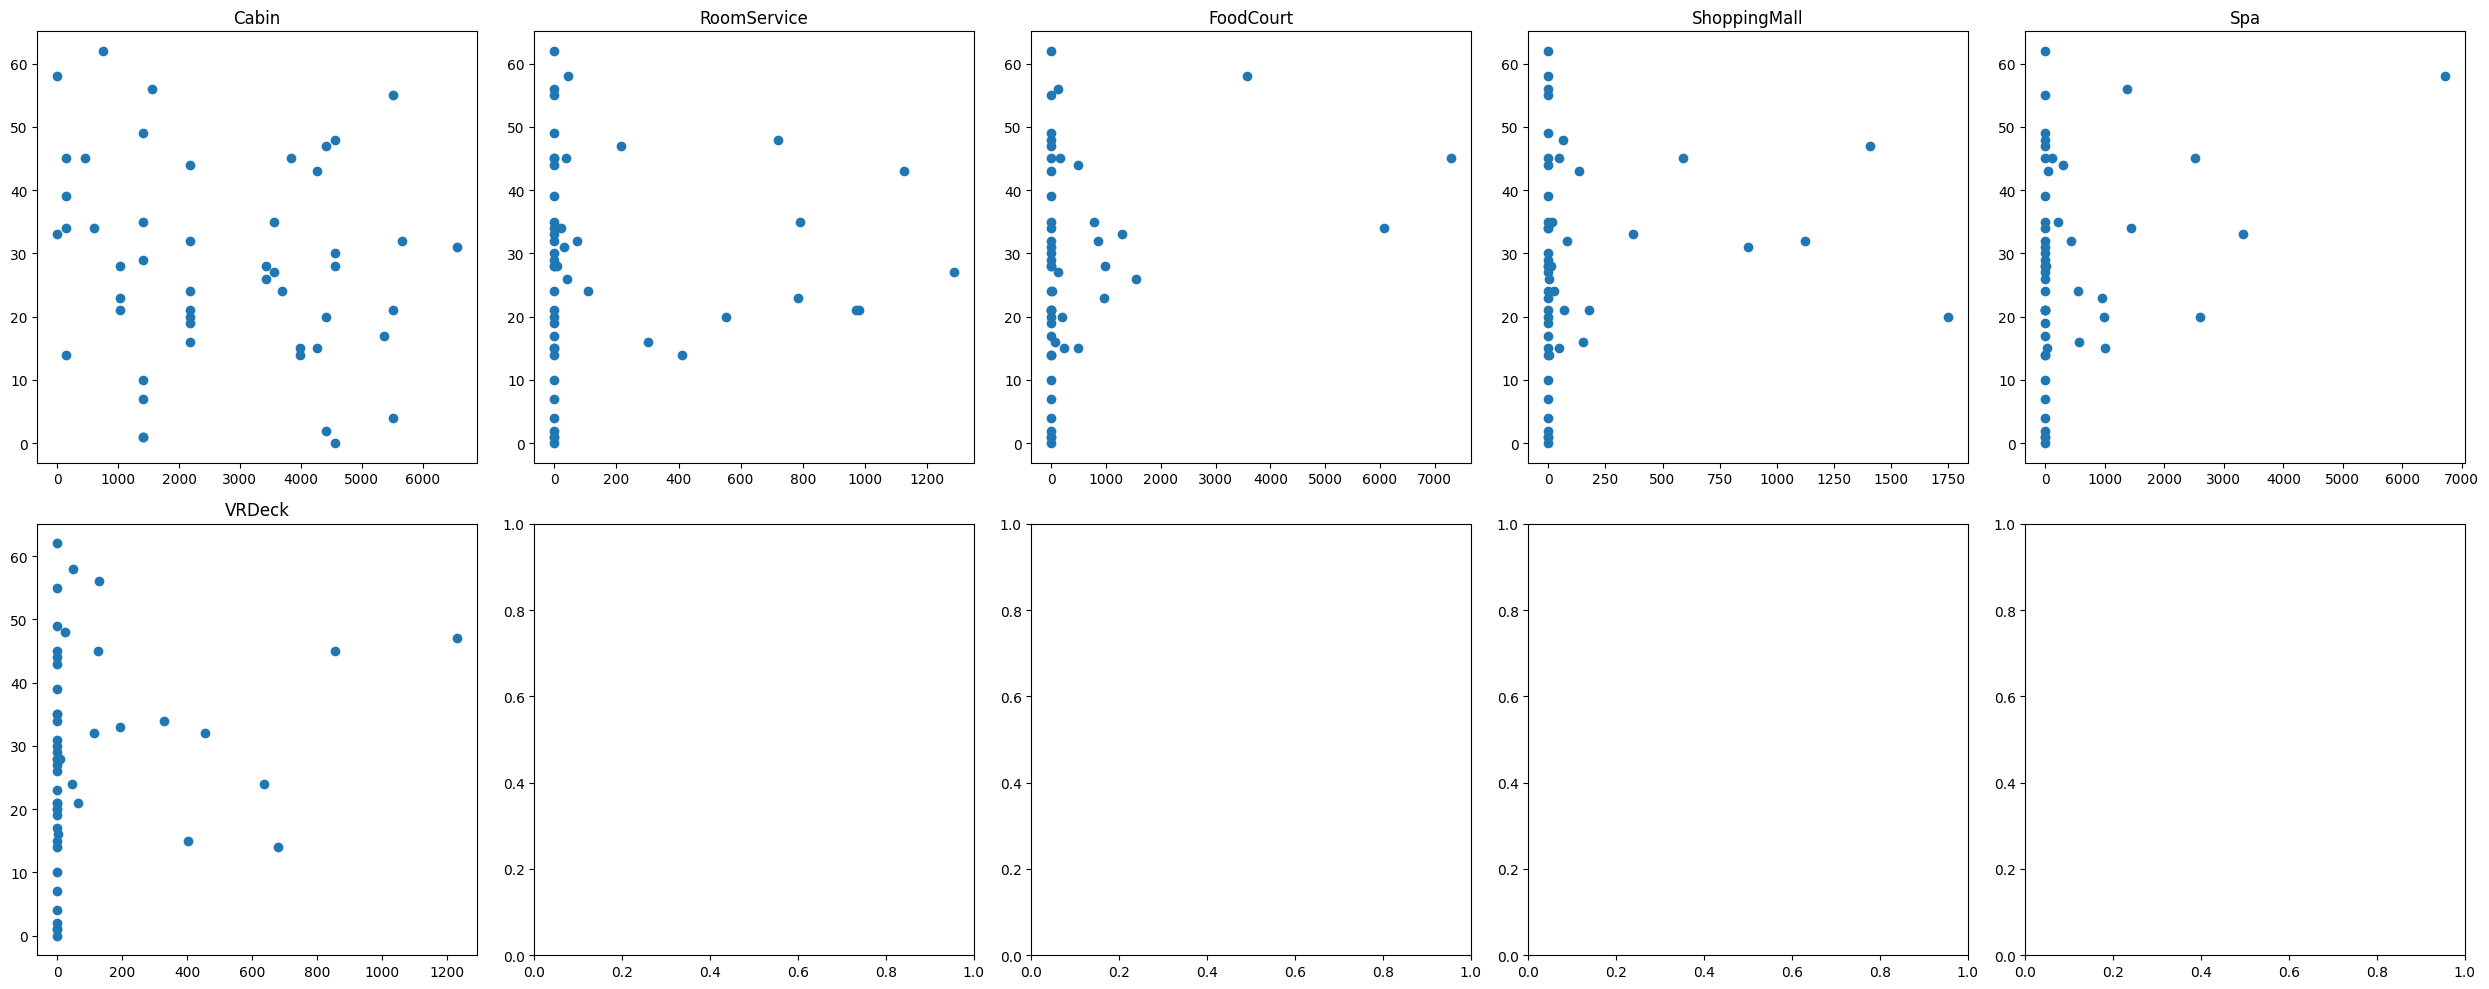

In [7]:
# --- [CELL 6]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
# === BEFORE (original) ===
# # Vemos la relación de cada variable con la variable Y
# filas = 2
# col = 5
# 
# nombres_col = df[["Cabin", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]]
# y = df["Age"]
# 
# # N es la cantidad de datos con los que trabajaremos. Se usa más adelante, atención!!
# N = 50
# fig, axs = plt.subplots(filas, col, figsize=(25, 10))
# 
# for i in range(filas):
#     for j in range(col):
#         n = i * col + j
#         if n < len(nombres_col):
#             axs[i, j].set_title(nombres_col.columns[n])
#             axs[i, j].scatter(df[nombres_col.columns[n]][:N], y[:N])
# 
# fig.tight_layout()
# plt.show()

# === AFTER (edited) ===
filas = 2
col = 5

nombres_col = df[["Cabin", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]]
y = df["Age"]


N = 50
fig, axs = plt.subplots(filas, col, figsize=(25, 10))

for i in range(filas):
    for j in range(col):
        n = i * col + j
        if n < len(nombres_col.columns):
            axs[i, j].set_title(nombres_col.columns[n])
            axs[i, j].scatter(df[nombres_col.columns[n]][:N], y[:N])

fig.tight_layout()
plt.show()

In [8]:
titles = [ax.get_title() for ax in axs.flatten()]
non_empty_titles = [t for t in titles if t]
expected_titles = list(nombres_col.columns)

assert len(titles) == filas * col, f"Expected {filas * col} subplot titles, got {len(titles)}"
assert non_empty_titles == expected_titles, (
    f"Expected plotted columns {expected_titles}, got {non_empty_titles}"
)
assert titles[len(expected_titles):] == [""] * (len(titles) - len(expected_titles)), (
    "Subplots beyond available columns should remain unused (empty title)."
)